Clustering Pixel Readout v0
===========================

- GAMPixPy output unit: cm, µs
- `trig t` is the timestamp where the trigger criterion is met
- `start t` is the timestamp the waveform record starts.  Now it is set to be 3 ticks before the trigger time
- `trig z` only matters if the event/interaction happens at t<sub>0</sub> = 0

In [1]:
import numpy as np
import pandas as pd
import h5py
import torch
import math

import matplotlib.pyplot as plt
import matplotlib.colors as colors

from sklearn.cluster import DBSCAN

In [2]:
edepsim_path = '/Users/yuntse/data/lartpc_rd/gampix/g4/radiologicals/fullgeoanatruth-vd-reduced_g4_00.h5'
sim_output_path = '/Users/yuntse/data/lartpc_rd/gampix/detsim/radiologicals/gampixpy_fullgeoanatruth-vd-reduced_g4_00_2Mhz_segmentlabel_lowtrig_5mmpitch_presample.h5'

In [3]:
# GAMPixPy outputs
with h5py.File(sim_output_path, 'r') as simf:
    # Print all top-level groups/datasets
    print(list(simf.keys()))
    fT = simf['tiles']
    fP = simf['pixels']
    fM = simf['meta']
    print(fT.dtype)
    print(fP.dtype)
    print(fM.dtype)

    tempT = fT[()]
    tempP = fP[()]
    tempM = fM[()]

['meta', 'pixels', 'tiles']
[('event id', '<u4'), ('tile trigger id', '<u4'), ('tile tpc', '<u4'), ('tile x', '<f4'), ('tile y', '<f4'), ('trig z', '<f4'), ('trig t', '<f4'), ('start t', '<f4'), ('waveform', '<f4', (20,)), ('raw waveform', '<f4', (20,)), ('attribution', '<f4', (20, 3)), ('label', '<i4', (3,))]
[('event id', '<u4'), ('tile trigger id', '<u4'), ('pixel tpc', '<u4'), ('pixel x', '<f4'), ('pixel y', '<f4'), ('trig z', '<f4'), ('trig t', '<f4'), ('start t', '<f4'), ('waveform', '<f4', (20,)), ('raw waveform', '<f4', (20,)), ('attribution', '<f4', (20, 3)), ('label', '<i4', (3,))]
[('event id', '<u4'), ('primary energy', '<f4'), ('deposited charge', '<f4'), ('vertex x', '<f4'), ('vertex y', '<f4'), ('vertex z', '<f4'), ('theta', '<f4'), ('phi', '<f4'), ('primary length', '<f4')]


In [4]:
dT = pd.DataFrame({
    name: tempT[name].tolist() if tempT[name].ndim > 1 else tempT[name]
    for name in tempT.dtype.names
})
dT

,event id,tile trigger id,tile tpc,tile x,tile y,trig z,trig t,start t,waveform,raw waveform,attribution,label
0,0,0,0,-1065.0,-575.0,929.928528,5807.936523,5806.436523,"[71.51425170898438, 23.693281173706055, 110.85...","[40.419734954833984, 54.4290771484375, 108.858...","[[1.0, 0.0, 0.0], [0.866381824016571, 0.133618...","[8158, 8157, -9999]"
1,0,1,0,-1065.0,-535.0,1021.513367,6379.936523,6378.436523,"[83.48052978515625, 146.16305541992188, 64.973...","[54.128074645996094, 40.22443389892578, 113.96...","[[0.8669896125793457, 0.1330103874206543, 0.0]...","[8100, 8099, -9999]"
2,0,2,0,-1055.0,-575.0,-568.252625,-3549.063477,-3550.563477,"[44.01643753051758, 82.82003784179688, -27.321...","[0.0, 0.0, 0.0, 226.1931915283203, 0.0, 0.0, 0...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[7192, 7191, 5816]"
3,0,3,0,-1055.0,-575.0,-497.882812,-3109.563477,-3111.063477,"[44.114898681640625, 37.47757339477539, 17.330...","[0.0, 0.0, 0.0, 296.6054382324219, 998.5713500...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[5816, 7192, 7191]"
4,0,4,0,-1055.0,-565.0,-504.847748,-3153.063477,-3154.563477,"[44.97030258178711, -49.88114547729492, 50.881...","[0.0, 0.0, 40.62684631347656, 703.810974121093...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.73608815...","[5812, 5811, 8161]"
...,...,...,...,...,...,...,...,...,...,...,...,...
888942,999,903,0,-735.0,-485.0,-497.442932,-3106.816162,-3108.316162,"[-8.264322280883789, 69.99140930175781, 66.293...","[0.0, 0.0, 89.52598571777344, 514.770324707031...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.88114064...","[8828755, 8828754, 8828756]"
888943,999,904,0,-735.0,-485.0,-489.277130,-3055.816162,-3057.316162,"[-5.47781229019165, 47.436580657958984, 127.23...","[0.0, 0.0, 68.75830078125, 1011.7266845703125,...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, ...","[8828761, 8828763, 8828760]"
888944,999,905,0,-735.0,-365.0,356.682068,2227.683838,2226.183838,"[-21.35822868347168, -5.267505168914795, 56.85...","[0.0, 0.0, 10.029180526733398, 704.94403076171...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, ...","[8830264, 8830263, 8830266]"
888945,999,906,0,-735.0,-355.0,381.499634,2382.683838,2381.183838,"[24.006847381591797, -3.346813201904297, 108.2...","[33.54474639892578, 20.133268356323242, 134.18...","[[0.3999064862728119, 0.19995900988578796, 0.2...","[8833149, 8833150, 8833151]"


In [5]:
dP = pd.DataFrame({
    name: tempP[name].tolist() if tempP[name].ndim > 1 else tempP[name]
    for name in tempP.dtype.names
})
dP

,event id,tile trigger id,pixel tpc,pixel x,pixel y,trig z,trig t,start t,waveform,raw waveform,attribution,label
0,0,0,0,-1067.25,-575.25,929.688354,5806.436523,5806.436523,"[108.91615295410156, 40.565067291259766, 11.50...","[13.47323989868164, 6.736626625061035, 20.7459...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.64943969...","[8158, 8157, -9999]"
1,0,0,0,-1066.75,-575.25,929.688354,5806.436523,5806.436523,"[-25.368637084960938, 24.747264862060547, 7.89...","[13.473246574401855, 20.209869384765625, 6.736...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, ...","[8158, 8157, -9999]"
2,0,1,0,-1064.75,-534.75,1021.273193,6378.436523,6378.436523,"[-50.46127700805664, 45.12648391723633, -15.13...","[27.31180191040039, 6.704076290130615, 46.9284...","[[0.2636075019836426, 0.7363925576210022, 0.0]...","[8099, 8100, -9999]"
3,0,1,0,-1064.75,-534.25,1021.273193,6378.436523,6378.436523,"[23.731115341186523, 8.74952507019043, -45.965...","[0.0, 6.704071521759033, 20.112199783325195, 2...","[[0.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 1.0, ...","[8099, 8100, -9999]"
4,0,2,0,-1053.25,-571.75,-568.492798,-3550.563477,-3550.563477,"[11.579497337341309, -44.413578033447266, 13.0...","[0.0, 0.0, 0.0, 154.22262573242188, 0.0, 0.0, ...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[7192, -9999, -9999]"
...,...,...,...,...,...,...,...,...,...,...,...,...
3141157,999,907,0,-733.75,-351.25,386.943481,2416.683838,2416.683838,"[-24.71961212158203, -21.30653953552246, 39.62...","[26.738685607910156, 20.05402183532715, 33.530...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.79744172...","[8833147, 8833148, 8833145]"
3141158,999,907,0,-733.75,-350.75,386.943481,2416.683838,2416.683838,"[-32.043785095214844, 6.9720072746276855, 11.4...","[0.0, 0.0, 0.0, 26.7386417388916, 6.6846628189...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[8833147, 8833148, 8833146]"
3141159,999,907,0,-733.25,-351.75,386.943481,2416.683838,2416.683838,"[79.06653594970703, 8.314297676086426, 6.99862...","[0.0, 0.0, 6.684662818908691, 33.4232788085937...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, ...","[8833147, 8833148, -9999]"
3141160,999,907,0,-733.25,-351.25,386.943481,2416.683838,2416.683838,"[50.43720626831055, -33.99485397338867, -29.40...","[20.05394744873047, 6.6846923828125, 6.6846632...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, ...","[8833147, 8833148, -9999]"


In [6]:
# edep-sim output for truth matching
with h5py.File(edepsim_path, 'r') as fg4:
    # Print all top-level groups/datasets
    print(list(fg4.keys()))
    fS = fg4['segments']
    # fT = fg4['trajectories']
    # fV = fg4['vertices']
    print(fS.dtype)
    # print(fT.dtype)
    # print(fV.dtype)
    
    tempS = fS[()]
    # tempT = fT[()]
    # tempV = fV[()]

['segments', 'trajectories', 'vertices']
{'names': ['event_id', 'vertex_id', 'file_vertex_id', 'segment_id', 'z_end', 'traj_id', 'file_traj_id', 'tran_diff', 'z_start', 'x_end', 'y_end', 'n_electrons', 'pdg_id', 'x_start', 'y_start', 't_start', 't0_start', 't0_end', 't0', 'dx', 'long_diff', 'pixel_plane', 't_end', 'dEdx', 'dE2dx', 'dE', 'dE2', 't', 'y', 'x', 'z', 'n_photons'], 'formats': ['<u4', '<u8', '<u8', '<u4', '<f4', '<i4', '<u4', '<f4', '<f4', '<f4', '<f4', '<u4', '<i4', '<f4', '<f4', '<f4', '<f8', '<f8', '<f8', '<f4', '<f4', '<i4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4'], 'offsets': [0, 8, 16, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 72, 80, 88, 96, 104, 108, 112, 116, 120, 124, 128, 132, 136, 140, 144, 148, 152], 'itemsize': 160}


In [7]:
dS = pd.DataFrame(tempS)
dS

,event_id,vertex_id,file_vertex_id,segment_id,z_end,traj_id,file_traj_id,tran_diff,z_start,x_end,...,t_end,dEdx,dE2dx,dE,dE2,t,y,x,z,n_photons
0,0,2166,2166,0,98.670486,2166,2166,0.0,98.706284,348.101868,...,0.0,0.063558,0.0,0.003178,0.0,0.0,-438.227661,348.086365,98.688385,0.0
1,0,2166,2166,1,98.668915,2168,2168,0.0,98.670486,348.104218,...,0.0,27.031174,0.0,0.089725,0.0,0.0,-438.236572,348.103027,98.669701,0.0
2,0,2166,2166,2,104.624596,2167,2167,0.0,104.624336,342.946564,...,0.0,50.987686,0.0,0.038659,0.0,0.0,-435.562378,342.946808,104.624466,0.0
3,0,2165,2165,3,283.540466,2165,2165,0.0,283.542053,349.946442,...,0.0,0.063542,0.0,0.003178,0.0,0.0,-332.630402,349.921570,283.541260,0.0
4,0,2165,2165,4,283.536835,2170,2170,0.0,283.540466,349.951935,...,0.0,20.367743,0.0,0.134589,0.0,0.0,-332.627686,349.949188,283.538635,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8835149,999,3,2090281,8835149,98.972160,3,7541269,0.0,98.977150,-118.376740,...,0.0,21.503775,0.0,0.124119,0.0,0.0,-469.179474,-118.378151,98.974655,0.0
8835150,999,2,2090280,8835150,112.352966,2,7541268,0.0,112.353348,-321.522552,...,0.0,26.071560,0.0,0.095099,0.0,0.0,-448.416565,-321.521240,112.353157,0.0
8835151,999,1,2090279,8835151,43.172062,1,7541267,0.0,43.163631,111.662086,...,0.0,16.500298,0.0,0.185769,0.0,0.0,-398.363098,111.664001,43.167847,0.0
8835152,999,1,2090279,8835152,43.172062,1,7541267,0.0,43.172062,111.662086,...,0.0,0.000000,0.0,0.000002,0.0,0.0,-398.366302,111.662086,43.172062,0.0


In [8]:
dP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3141162 entries, 0 to 3141161
Data columns (total 12 columns):
 #   Column           Dtype  
---  ------           -----  
 0   event id         uint32 
 1   tile trigger id  uint32 
 2   pixel tpc        uint32 
 3   pixel x          float32
 4   pixel y          float32
 5   trig z           float32
 6   trig t           float32
 7   start t          float32
 8   waveform         object 
 9   raw waveform     object 
 10  attribution      object 
 11  label            object 
dtypes: float32(5), object(4), uint32(3)
memory usage: 191.7+ MB


## Match Pixel Channels to Tiles

In [9]:
pixels = dP.copy()
pixels["_pixel_index"] = pixels.index

# Preserve the original tile dataframe index as tile_id
tiles = dT.reset_index(names = "tile_id").copy()

# A 10x10cm2 tile centered at (tile x, tile y)
tile_size = 10
half_size = tile_size / 2

x0 = tiles["tile x"].min()
y0 = tiles["tile y"].min()

# Tile index for each tile row
tiles["tile_ix"] = np.rint(
    (tiles["tile x"] - x0) / tile_size
).astype("int64")

tiles["tile_iy"] = np.rint(
    (tiles["tile y"] - y0) / tile_size
).astype("int64")

# Tile index for each pixel row
pixels["tile_ix"] = np.floor(
    (pixels["pixel x"] - (x0 - half_size)) / tile_size
).astype("int64")

pixels["tile_iy"] = np.floor(
    (pixels["pixel y"] - (y0 - half_size)) / tile_size
).astype("int64")

In [10]:
pixels["tile_ix"].min(), pixels["tile_iy"].min(), pixels["tile_ix"].max(), pixels["tile_iy"].max()

(0, 0, 62, 67)

In [11]:
tiles["tile_ix"].min(), tiles["tile_iy"].min(), tiles["tile_ix"].max(), tiles["tile_iy"].max()

(0, 0, 62, 67)

In [12]:
# Candidate tile-pixel pairs from the same event
candidates = pixels.merge(
    tiles[
        [
            "tile_id",
            "event id",
            "tile_ix",
            "tile_iy",
            "start t",
        ]
    ],
    on = ["event id", "tile_ix", "tile_iy"],
    how = "left",
    suffixes = ("_pixel", "_tile"),
)


# Match using:
# tile start t <= pixel start t < tile start t + 10

is_match = (
    (candidates["start t_tile"] - 1. <= candidates["start t_pixel"])
    & (
        candidates["start t_pixel"]
        < candidates["start t_tile"] + 10
    )
)

matches = candidates.loc[
    is_match,
    ["_pixel_index", "tile_id", "start t_pixel", "start t_tile"],
]

matches = (
    matches
    .sort_values(
        ["_pixel_index", "start t_tile"],
        ascending = [True, False],
    )
    .drop_duplicates("_pixel_index")
)

tile_id_by_pixel = (
    matches
    .set_index("_pixel_index")["tile_id"]
)

dP["tile_id"] = (
    dP.index.to_series()
    .map(tile_id_by_pixel)
)

In [13]:
dT.index.dtype

dtype('int64')

In [14]:
dP["tile_id"].isna().sum()

np.int64(0)

In [15]:
unmatched = dP[dP["tile_id"].isna()]
unmatched

,event id,tile trigger id,pixel tpc,pixel x,pixel y,trig z,trig t,start t,waveform,raw waveform,attribution,label,tile_id


## Testing DBSCAN

- Use `pixel x`, `pixel y`, and `start t`
- Pixel pitch: 0.5cm
- Time sampling rate: 0.5µs, corresponding to 0.8mm
- Use slightly looser criterion along the time coordinate, 0.8cm
- min_samples = 2

In [16]:
# Normalize to the eps unit.
# currently use a single pixel pitch and 10 time ticks
space_scale = 0.5
time_scale = 0.08*10
# DBSCAN distance.  Now using ~sqrt(2)*(pixel pitch = 0.5cm)
eps = 1.5
min_samples = 2

In [17]:
def cluster_event(g):
    X = g[['pixel x', 'pixel y', 'start t']].to_numpy(dtype = float)

    X[:, 0] /= space_scale
    X[:, 1] /= space_scale
    X[:, 2] /= time_scale

    labels = DBSCAN(eps = eps, min_samples = min_samples).fit_predict(X)
    return g.assign(cluster = labels)

In [18]:
dPCluster1 = (
    dP.groupby('event id', group_keys = False)
      .apply(cluster_event)
)
dPCluster1

/var/folders/bn/24gl1c290ls54cq54cz7rt9sfm8jyc/T/ipykernel_18712/2521824139.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(cluster_event)


,event id,tile trigger id,pixel tpc,pixel x,pixel y,trig z,trig t,start t,waveform,raw waveform,attribution,label,tile_id,cluster
0,0,0,0,-1067.25,-575.25,929.688354,5806.436523,5806.436523,"[108.91615295410156, 40.565067291259766, 11.50...","[13.47323989868164, 6.736626625061035, 20.7459...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.64943969...","[8158, 8157, -9999]",0,0
1,0,0,0,-1066.75,-575.25,929.688354,5806.436523,5806.436523,"[-25.368637084960938, 24.747264862060547, 7.89...","[13.473246574401855, 20.209869384765625, 6.736...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, ...","[8158, 8157, -9999]",0,0
2,0,1,0,-1064.75,-534.75,1021.273193,6378.436523,6378.436523,"[-50.46127700805664, 45.12648391723633, -15.13...","[27.31180191040039, 6.704076290130615, 46.9284...","[[0.2636075019836426, 0.7363925576210022, 0.0]...","[8099, 8100, -9999]",1,1
3,0,1,0,-1064.75,-534.25,1021.273193,6378.436523,6378.436523,"[23.731115341186523, 8.74952507019043, -45.965...","[0.0, 6.704071521759033, 20.112199783325195, 2...","[[0.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 1.0, ...","[8099, 8100, -9999]",1,1
4,0,2,0,-1053.25,-571.75,-568.492798,-3550.563477,-3550.563477,"[11.579497337341309, -44.413578033447266, 13.0...","[0.0, 0.0, 0.0, 154.22262573242188, 0.0, 0.0, ...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[7192, -9999, -9999]",2,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3141157,999,907,0,-733.75,-351.25,386.943481,2416.683838,2416.683838,"[-24.71961212158203, -21.30653953552246, 39.62...","[26.738685607910156, 20.05402183532715, 33.530...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.79744172...","[8833147, 8833148, 8833145]",888946,741
3141158,999,907,0,-733.75,-350.75,386.943481,2416.683838,2416.683838,"[-32.043785095214844, 6.9720072746276855, 11.4...","[0.0, 0.0, 0.0, 26.7386417388916, 6.6846628189...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, ...","[8833147, 8833148, 8833146]",888946,741
3141159,999,907,0,-733.25,-351.75,386.943481,2416.683838,2416.683838,"[79.06653594970703, 8.314297676086426, 6.99862...","[0.0, 0.0, 6.684662818908691, 33.4232788085937...","[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [1.0, 0.0, ...","[8833147, 8833148, -9999]",888946,741
3141160,999,907,0,-733.25,-351.25,386.943481,2416.683838,2416.683838,"[50.43720626831055, -33.99485397338867, -29.40...","[20.05394744873047, 6.6846923828125, 6.6846632...","[[1.0, 0.0, 0.0], [1.0, 0.0, 0.0], [1.0, 0.0, ...","[8833147, 8833148, -9999]",888946,741


In [19]:
tiles_per_cluster = (
    dPCluster1[
        dPCluster1["cluster"] != -1
    ]
    .groupby(["event id", "cluster"], dropna = False)["tile_id"]
    .nunique(dropna = True)
    .reset_index(name = "n_tiles")
)

In [20]:
tiles_per_cluster

,event id,cluster,n_tiles
0,0,0,1
1,0,1,1
2,0,2,1
3,0,3,1
4,0,4,1
...,...,...,...
716281,999,737,1
716282,999,738,1
716283,999,739,1
716284,999,740,1


In [21]:
tiles_per_cluster.n_tiles.min(), tiles_per_cluster.n_tiles.max()

(1, 4)

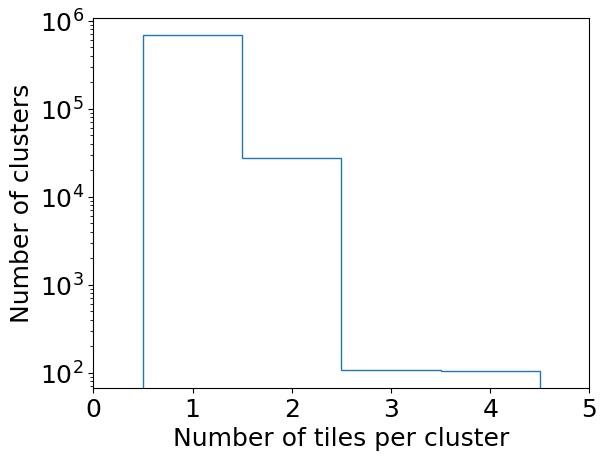

In [22]:
plt.rcParams.update({"font.size": 18})
fig, ax = plt.subplots()

Bins = np.linspace(-0.5, 4.5, 6)

ax.hist(tiles_per_cluster.n_tiles, bins = Bins, histtype = 'step')

ax.set_xlabel('Number of tiles per cluster')
ax.set_ylabel('Number of clusters')
ax.set_xlim([0, 5])
ax.set_yscale('log')

In [23]:
(dPCluster1["cluster"] == -1).sum()

np.int64(167412)

In [24]:
clusters_per_tile = (
    dPCluster1[
        (dPCluster1["cluster"] != -1)
        & dPCluster1["tile_id"].notna()
    ]
    .groupby(["event id", "tile_id"])["cluster"]
    .nunique()
    .reset_index(name="n_clusters")
)

clusters_per_tile

,event id,tile_id,n_clusters
0,0,0,1
1,0,1,1
2,0,3,1
3,0,4,1
4,0,7,1
...,...,...,...
740285,999,888940,1
740286,999,888942,1
740287,999,888943,1
740288,999,888945,1


In [25]:
clusters_per_tile.n_clusters.min(), clusters_per_tile.n_clusters.max()

(1, 4)

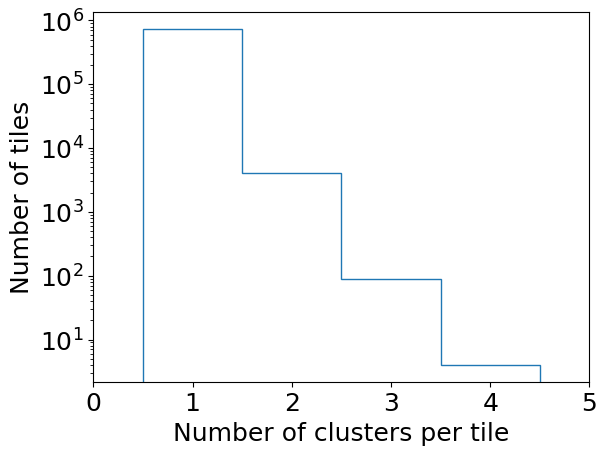

In [26]:
plt.rcParams.update({"font.size": 18})
fig, ax = plt.subplots()

Bins = np.linspace(-0.5, 4.5, 6)

ax.hist(clusters_per_tile.n_clusters, bins = Bins, histtype = 'step')

ax.set_xlabel('Number of clusters per tile')
ax.set_ylabel('Number of tiles')
ax.set_xlim([0, 5])
ax.set_yscale('log')

In [27]:
(dPCluster1["cluster"] == -1).sum()

np.int64(167412)

In [28]:
167412/3141162

0.05329620057800266

### Unclustered pixel channels

In [29]:
dPUnclustered1 = dPCluster1[
    dPCluster1["cluster"] == -1
].copy()

In [30]:
# 1. Weighted average of x over the matched dS rows:
#    x_weighted = sum(dE * x) / sum(dE)
# 2. Find the pdg code for the largest dE
# 3. Count how many segments in one unclustered unit

group_vars = [
    "event id", 
    "pixel x", 
    "pixel y", 
    "start t"
]

# 1) explode labels to long form
dPUnclustered1_long = (
    dPUnclustered1[ group_vars + ["label"]]
    .explode("label", ignore_index = True)
    .rename(columns = {"label": "segment_id"})
)

# 2) drop padding
dPUnclustered1_long = dPUnclustered1_long[dPUnclustered1_long["segment_id"].ne(-9999)]

# 3) join to dS on event + segment
m = dPUnclustered1_long.merge(
    dS[["event_id", "segment_id", "dE", "x", "pdg_id"]],
    left_on = ["event id", "segment_id"],
    right_on = ["event_id", "segment_id"],
    how = "inner",
)

# numerator and denominator
m["dE_x"] = m["dE"] * m["x"]

# Index of the row with the largest dE in each group
idx_max_dE = m.groupby(group_vars)["dE"].idxmax()

# pdg_id associated with that largest dE
pdg_id_max_dE = (
    m.loc[idx_max_dE, group_vars + ["pdg_id"]]
)

# sum over dE and dE*x
agg = (
    m.groupby(group_vars, sort = False, as_index = False)
     .agg(E = ("dE", "sum"), dE_x_sum = ("dE_x", "sum"),
          z_mean = ("x", "mean"), z_std = ("x", "std"),
          z_min = ("x", "min"), z_max = ("x", "max"),
          nSegments = ("dE", "count"))
     .merge(
        pdg_id_max_dE,
        on = group_vars,
        how = "left",
    )
)

agg["z_avg"] = agg["dE_x_sum"] / agg["E"]

# attach back to dT2
dPUnclustered1 = dPUnclustered1.merge(agg[group_vars + ["E", "z_avg", "z_mean", "z_std", "z_min", "z_max", "nSegments", "pdg_id"]],
                                      on = group_vars, how = "left")

# handle no-match (or zero total energy) rows
dPUnclustered1["E"] = dPUnclustered1["E"].fillna(0.0)
dPUnclustered1["z_avg"] = dPUnclustered1["z_avg"].where(dPUnclustered1["E"] > 0, np.nan)
dPUnclustered1['drift_avg'] = 325 - dPUnclustered1["z_avg"]

In [31]:
dPUnclustered1

,event id,tile trigger id,pixel tpc,pixel x,pixel y,trig z,trig t,start t,waveform,raw waveform,...,cluster,E,z_avg,z_mean,z_std,z_min,z_max,nSegments,pdg_id,drift_avg
0,0,2,0,-1053.25,-571.75,-568.492798,-3550.563477,-3550.563477,"[11.579497337341309, -44.413578033447266, 13.0...","[0.0, 0.0, 0.0, 154.22262573242188, 0.0, 0.0, ...",...,-1,0.034409,323.147705,323.147705,NaN,323.147705,323.147705,1,11,1.852295
1,0,5,0,-1052.75,-494.25,528.764343,3302.436523,3302.436523,"[-25.747671127319336, -6.963047504425049, 25.6...","[0.0, 0.0, 30.53779411315918, 203.585235595703...",...,-1,0.035624,317.780304,317.780304,NaN,317.780304,317.780304,1,11,7.219696
2,0,6,0,-1052.75,-494.75,532.847290,3327.936523,3327.936523,"[-8.300935745239258, 45.28941345214844, 6.5868...","[0.0, 0.0, 32.17604064941406, 552.898193359375...",...,-1,0.067363,313.684540,313.695801,0.017630,313.683350,313.708282,2,11,11.315460
3,0,13,0,-1045.75,-489.25,523.880920,3271.936523,3271.936523,"[-51.97883987426758, 36.6081428527832, 48.8428...","[0.0, 0.0, 10.228135108947754, 153.42202758789...",...,-1,0.028190,322.682434,322.682434,NaN,322.682434,322.682434,1,11,2.317566
4,0,14,0,-1040.25,-467.75,590.808289,3689.936523,3689.936523,"[-93.20195007324219, 143.80487060546875, 22.98...","[17.23822021484375, 43.095550537109375, 77.571...",...,-1,0.075690,68.326797,68.326797,NaN,68.326797,68.326797,1,11,256.673218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167407,999,879,0,-754.25,-372.75,-370.793213,-2315.816162,-2315.816162,"[57.61266326904297, -47.37300109863281, -44.50...","[0.0, 0.0, 0.0, 1581.224853515625, 4303.327148...",...,-1,0.324344,324.782837,324.782837,NaN,324.782837,324.782837,1,11,0.217163
167408,999,896,0,-746.25,-409.25,-42.240505,-263.816162,-263.816162,"[46.23585510253906, 63.23639678955078, 56.6926...","[0.0, 0.0, 49.86405944824219, 6542.24365234375...",...,-1,0.462395,318.922180,318.927887,0.013940,318.918030,318.937744,2,11,6.077820
167409,999,900,0,-747.25,-369.75,-164.807327,-1029.316162,-1029.316162,"[28.12889289855957, 87.65311431884766, 146.967...","[0.0, 0.0, 128.88577270507812, 2547.9741210937...",...,-1,0.258631,307.677002,307.677002,NaN,307.677002,307.677002,1,11,17.322998
167410,999,902,0,-733.75,-488.25,-520.259094,-3249.316162,-3249.316162,"[-37.58879470825195, 77.59310913085938, -93.69...","[0.0, 0.0, 0.0, 1831.2508544921875, 0.0, 0.0, ...",...,-1,0.134956,323.696960,323.696960,NaN,323.696960,323.696960,1,11,1.303040


In [32]:
dPUnclustered1.pdg_id.unique()

array([        11, 1000020040,        -11], dtype=int32)

In [33]:
dPUnclustered1.E.min(), dPUnclustered1.E.max()

(0.004410484340041876, 9.220512390136719)

In [34]:
dPUnclustered1.nSegments.min(), dPUnclustered1.nSegments.max()

(1, 3)

(0.0, 4.0)

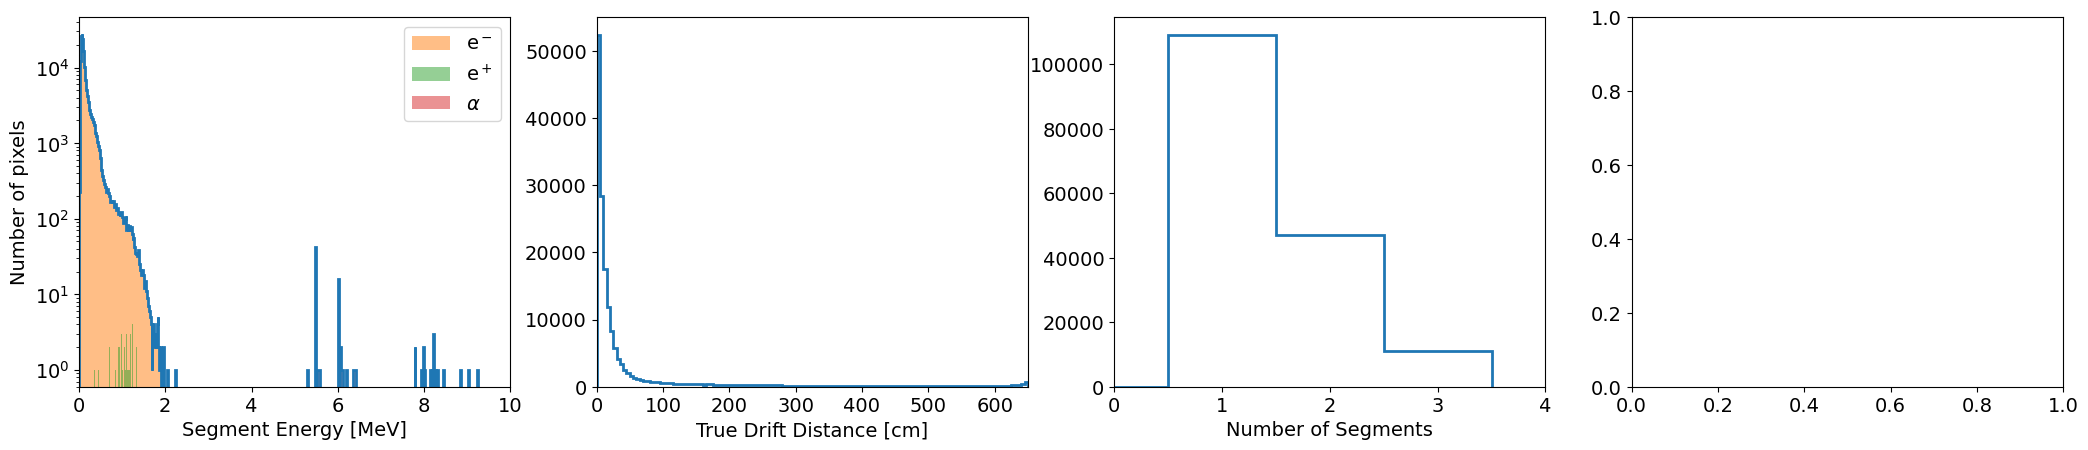

In [37]:
plt.rcParams.update({"font.size": 14})
fig, ax = plt.subplots(1, 4, figsize = (25.6, 4.8))

ax[0].hist(dPUnclustered1['E'], bins = np.linspace(0, 10, 501), histtype = 'step', linewidth = 2)
ax[0].hist(dPUnclustered1.loc[dPUnclustered1.pdg_id == 11, 'E'], bins = np.linspace(0, 10, 501), alpha = 0.5, label = r'e$^-$')
ax[0].hist(dPUnclustered1.loc[dPUnclustered1.pdg_id == -11, 'E'], bins = np.linspace(0, 10, 501), alpha = 0.5, label = r'e$^+$')
ax[0].hist(dPUnclustered1.loc[dPUnclustered1.pdg_id == 1000020040, 'E'], bins = np.linspace(0, 10, 501), alpha = 0.5, label = r'$\alpha$')
ax[0].set_xlabel('Segment Energy [MeV]')
ax[0].set_xlim([0, 10])
ax[0].set_ylabel('Number of pixels')
ax[0].set_yscale('log')
ax[0].legend()


ax[1].hist(dPUnclustered1['drift_avg'], bins = np.linspace(0, 650, 131), histtype = 'step', linewidth = 2)
ax[1].set_xlabel('True Drift Distance [cm]')
ax[1].set_xlim([0, 650])

ax[2].hist(dPUnclustered1['nSegments'], bins = np.linspace(-0.5, 3.5, 5), histtype = 'step', linewidth = 2)
ax[2].set_xlabel('Number of Segments')
ax[2].set_xlim([0, 4])

